# Notebook 4 — LIDC Concept Extraction (Concept Bottleneck için altyapı)

**Amaç:** Concept Bottleneck Multi-task Model için LIDC'nin 8 radyolojik karakteristiğini çıkar, mevcut `nodules.csv` ve `patches_*.h5` dosyalarına ekle.

**8 concept:**

| # | Concept | Aralık | Klinik anlamı |
|---|---|---|---|
| 1 | subtlety | 1-5 | Ne kadar belirgin / zor görünüyor |
| 2 | internalStructure | 1-4 | Soft tissue / fluid / fat / air |
| 3 | calcification | 1-6 | Kireçlenme paterni |
| 4 | sphericity | 1-5 | Yuvarlaklık (1=düz, 5=küresel) |
| 5 | margin | 1-5 | Sınır keskinliği |
| 6 | lobulation | 1-5 | Loblanma derecesi |
| 7 | spiculation | 1-5 | Iğneleşme (malignite ile yüksek korelasyon) |
| 8 | texture | 1-5 | Non-solid → solid spektrumu |

Her cluster'da 4 radyolog değer verir, **ortalamayı alıyoruz** (malignancy gibi).

**Pipeline:**
1. pylidc setup (Notebook 1'deki monkey-patch)
2. Tüm LIDC scan'leri gez, her nodule cluster için 8 concept ortalaması (~5 dk)
3. `nodules.csv`'yi 8 yeni kolonla update et
4. `patches_train.h5`, `_val.h5`, `_test.h5` dosyalarına her sample için `(8,)` concept vektörü ekle
5. Sanity check: concept dağılımları + malignancy ile korelasyon matrisi

**Girdiler:**
- `nodules.csv` (Notebook 1)
- `patches_*.h5` (Notebook 3)

**Çıktılar:**
- `nodules.csv` (8 yeni kolonla güncellenmiş)
- `patches_*.h5`'lere `concepts` dataset eklenmiş (shape: N×8)

**Süre:** ~15-20 dakika


## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, time, h5py, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
print('Setup OK')

Mounted at /content/drive
Setup OK


## 2. Yollar

In [ ]:
NODULES_CSV = '/content/drive/MyDrive/bitirme/Finetune_Labels/nodules.csv'
TRAIN_H5    = '/content/drive/MyDrive/bitirme/Finetune_Patches/patches_train.h5'
VAL_H5      = '/content/drive/MyDrive/bitirme/Finetune_Patches/patches_val.h5'
TEST_H5     = '/content/drive/MyDrive/bitirme/Finetune_Patches/patches_test.h5'

# Yedek
NODULES_CSV_BACKUP = '/content/drive/MyDrive/bitirme/Finetune_Labels/nodules_pre_concepts.csv'

CONCEPT_COLS = [
    'subtlety_mean',
    'internalStructure_mean',
    'calcification_mean',
    'sphericity_mean',
    'margin_mean',
    'lobulation_mean',
    'spiculation_mean',
    'texture_mean',
]
N_CONCEPTS = len(CONCEPT_COLS)

# Spatial matching threshold for H5 lookup (mm)
SPATIAL_MATCH_THRESHOLD_MM = 5.0

print(f'{N_CONCEPTS} concept')

8 concept


## 3. pylidc setup (Notebook 1'deki monkey-patch ile)

In [ ]:
!pip install pylidc --quiet

import numpy as np
for _attr, _builtin in [('int', int), ('float', float), ('bool', bool), ('object', object)]:
    if not hasattr(np, _attr):
        setattr(np, _attr, _builtin)

# DICOM-less config
HOME = os.path.expanduser('~')
with open(os.path.join(HOME, '.pylidcrc'), 'w') as f:
    f.write('[dicom]\nwarn = False\n')

import pylidc as pl
n_scans = pl.query(pl.Scan).count()
n_anns = pl.query(pl.Annotation).count()
print(f'pylidc DB: {n_scans} scan, {n_anns} annotation')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 126.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 110.2 MB/s eta 0:00:00


/tmp/ipykernel_1528/1660621969.py:5: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _attr):


pylidc DB: 1018 scan, 6859 annotation


## 4. Mevcut nodules.csv'yi yükle ve yedekle

In [ ]:
nodules_df = pd.read_csv(NODULES_CSV)
print(f'nodules.csv: {len(nodules_df)} satır')
print(f'  Kolonlar: {list(nodules_df.columns)}')

# Yedek al — herhangi bir sorun olursa geri dön
if not os.path.exists(NODULES_CSV_BACKUP):
    nodules_df.to_csv(NODULES_CSV_BACKUP, index=False)
    print(f'  💾 Yedek: {NODULES_CSV_BACKUP}')
else:
    print(f'  Yedek zaten var: {NODULES_CSV_BACKUP}')

nodules.csv: 1100 satır
  Kolonlar: ['seriesuid', 'lidc_nodule_idx', 'coordX', 'coordY', 'coordZ', 'diameter_mm', 'malignancy_mean', 'malignancy_std', 'n_radiologists', 'malignancy_label', 'has_mask', 'mask_key', 'mask_voxel_count', 'bbox_zyx', 'n_candidates', 'match_distance_mm', 'annotation_ids']
  💾 Yedek: /content/drive/MyDrive/bitirme/Finetune_Labels/nodules_pre_concepts.csv


## 5. LIDC'den 8 concept çıkar

Her LIDC scan'ini gez, `cluster_annotations()` ile nodule cluster'larını al, her cluster için 8 concept ortalamasını hesapla. `(seriesuid, lidc_nodule_idx)` → 8 concept dict'i.

In [ ]:
print('LIDC concept extraction başlıyor...')
all_scans = pl.query(pl.Scan).all()
print(f'  Toplam scan: {len(all_scans)}')

# (seriesuid, lidc_nodule_idx) → {concept_mean dict}
concept_lookup = {}
n_processed = 0
n_skipped = 0

for scan in tqdm(all_scans, desc='Scans'):
    seriesuid = scan.series_instance_uid
    try:
        clusters = scan.cluster_annotations()
    except Exception as e:
        n_skipped += 1
        continue

    for nod_idx, cluster in enumerate(clusters):
        if len(cluster) == 0:
            continue
        # Aynı Notebook 1 filtresi
        if len(cluster) > 4:  # over-clustered, skip
            continue

        concept_lookup[(seriesuid, nod_idx)] = {
            'subtlety_mean':          float(np.mean([a.subtlety          for a in cluster])),
            'internalStructure_mean': float(np.mean([a.internalStructure for a in cluster])),
            'calcification_mean':     float(np.mean([a.calcification     for a in cluster])),
            'sphericity_mean':        float(np.mean([a.sphericity        for a in cluster])),
            'margin_mean':            float(np.mean([a.margin            for a in cluster])),
            'lobulation_mean':        float(np.mean([a.lobulation        for a in cluster])),
            'spiculation_mean':       float(np.mean([a.spiculation       for a in cluster])),
            'texture_mean':           float(np.mean([a.texture           for a in cluster])),
        }
        n_processed += 1

print(f'\nToplam concept çıkarılan nodule: {n_processed}')
print(f'Skipped scans: {n_skipped}')

LIDC concept extraction başlıyor...
  Toplam scan: 1018


Scans:   0%|          | 0/1018 [00:00<?, ?it/s]

Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some n

## 6. `nodules.csv`'ye 8 concept'i ekle

Mevcut nodules.csv'de `seriesuid + lidc_nodule_idx` üzerinden eşleşme yap.

In [ ]:
# 8 yeni kolonu sırayla ekle
for col in CONCEPT_COLS:
    nodules_df[col] = np.nan

# Her satır için lookup
n_matched = 0
n_unmatched = 0
for i, row in tqdm(nodules_df.iterrows(), total=len(nodules_df), desc='Merging'):
    key = (row['seriesuid'], int(row['lidc_nodule_idx']))
    if key in concept_lookup:
        for col in CONCEPT_COLS:
            nodules_df.at[i, col] = concept_lookup[key][col]
        n_matched += 1
    else:
        n_unmatched += 1

print(f'\n=== EŞLEŞTİRME ===')
print(f'  Eşleşen:    {n_matched} / {len(nodules_df)}')
print(f'  Eşleşmeyen: {n_unmatched}')

# Çıktıyı doğrula
print(f'\nConcept dağılımı ilk 5 satır:')
nodules_df[['seriesuid'] + CONCEPT_COLS].head()

Merging:   0%|          | 0/1100 [00:00<?, ?it/s]


=== EŞLEŞTİRME ===
  Eşleşen:    1088 / 1100
  Eşleşmeyen: 12

Concept dağılımı ilk 5 satır:


,seriesuid,subtlety_mean,internalStructure_mean,calcification_mean,sphericity_mean,margin_mean,lobulation_mean,spiculation_mean,texture_mean
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,3.666667,1.0,6.0,4.666667,4.333333,1.333333,1.333333,4.666667
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,4.000000,1.0,6.0,4.000000,4.500000,1.000000,1.000000,5.000000
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,3.333333,1.0,6.0,3.000000,3.666667,1.333333,1.333333,5.000000
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,4.750000,1.0,6.0,4.750000,4.250000,1.500000,1.500000,4.500000
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,5.000000,1.0,6.0,4.500000,5.000000,1.750000,1.250000,5.000000


## 7. nodules.csv'yi 8 concept ile üstüne yaz

In [ ]:
nodules_df.to_csv(NODULES_CSV, index=False)
print(f'✅ {NODULES_CSV} güncellendi')
print(f'   {len(nodules_df)} satır × {len(nodules_df.columns)} kolon')
print(f'\n8 concept kolonu:')
for col in CONCEPT_COLS:
    n_valid = nodules_df[col].notna().sum()
    mean = nodules_df[col].mean()
    print(f'  {col:30s}  {n_valid} valid, mean={mean:.2f}')

✅ /content/drive/MyDrive/bitirme/Finetune_Labels/nodules.csv güncellendi
   1100 satır × 25 kolon

8 concept kolonu:
  subtlety_mean                   1088 valid, mean=3.96
  internalStructure_mean          1088 valid, mean=1.01
  calcification_mean              1088 valid, mean=5.66
  sphericity_mean                 1088 valid, mean=3.79
  margin_mean                     1088 valid, mean=4.05
  lobulation_mean                 1088 valid, mean=1.75
  spiculation_mean                1088 valid, mean=1.61
  texture_mean                    1088 valid, mean=4.53


## 8. patches_*.h5 dosyalarına `concepts` dataset'i ekle

Her H5 örneği için:
- seriesuid + world_coord ile `nodules.csv`'de en yakın eşleşmeyi bul (KDTree, 5mm threshold)
- Eşleşirse 8 concept değerini al
- Eşleşmezse (negative örnek ya da no match) `-1.0` ile doldur (loss'ta ignore edilebilir)

In [ ]:
def add_concepts_to_h5(h5_path, nodules_df, concept_cols):
    '''H5'e (N, 8) shape'inde concepts dataset'i ekle.'''

    # nodules_df'i scan başına grupla, sadece concept'i olan satırlar
    valid_nodules = nodules_df.dropna(subset=concept_cols).copy()
    print(f'  Geçerli concept\'li nodule: {len(valid_nodules)}')

    # seriesuid → (coords array, concepts array)
    scan_lookup = {}
    for sid, group in valid_nodules.groupby('seriesuid'):
        coords = group[['coordX', 'coordY', 'coordZ']].values.astype(np.float32)
        concepts = group[concept_cols].values.astype(np.float32)
        scan_lookup[sid] = (coords, concepts)

    with h5py.File(h5_path, 'a') as h5:
        N = h5['patches'].shape[0]

        # Eski concepts dataset varsa sil
        if 'concepts' in h5:
            del h5['concepts']

        # Default: -1.0 (no match / negative)
        concepts_array = np.full((N, len(concept_cols)), -1.0, dtype=np.float32)

        # H5'teki tüm seriesuid ve world_coord'ları bir kerede oku
        seriesuids = h5['seriesuids'][:]
        world_coords = h5['world_coords'][:]
        detection = h5['detection'][:]

        n_matched = 0
        for idx in tqdm(range(N), desc=f'  Lookup [{os.path.basename(h5_path)}]'):
            if detection[idx] == 0:
                continue  # negative — concepts kalsın -1

            sid = seriesuids[idx]
            if isinstance(sid, bytes):
                sid = sid.decode('utf-8')

            if sid not in scan_lookup:
                continue

            coords, concepts = scan_lookup[sid]
            target = world_coords[idx]  # (X, Y, Z)

            # En yakın nodule
            dists = np.linalg.norm(coords - target, axis=1)
            nn = np.argmin(dists)

            if dists[nn] <= SPATIAL_MATCH_THRESHOLD_MM:
                concepts_array[idx] = concepts[nn]
                n_matched += 1

        # Yaz
        ds = h5.create_dataset('concepts', data=concepts_array, dtype='f4')
        ds.attrs['columns'] = ','.join(concept_cols)
        ds.attrs['n_concepts'] = len(concept_cols)
        ds.attrs['default_value'] = -1.0
        ds.attrs['note'] = '-1.0 = no match (negative sample veya spatial mismatch)'
        ds.attrs['threshold_mm'] = SPATIAL_MATCH_THRESHOLD_MM

        n_pos = int((detection == 1).sum())
        print(f'  Eşleşen pozitif: {n_matched}/{n_pos} ({n_matched/max(n_pos,1)*100:.1f}%)')
        return n_matched, n_pos

print('Fonksiyon tanımlandı ✅')

Fonksiyon tanımlandı ✅


## 9. Üç H5 dosyasını da güncelle

In [ ]:
results = {}
for split_name, h5_path in [('train', TRAIN_H5), ('val', VAL_H5), ('test', TEST_H5)]:
    print(f'\n=== {split_name.upper()} ===')
    n_match, n_pos = add_concepts_to_h5(h5_path, nodules_df, CONCEPT_COLS)
    results[split_name] = (n_match, n_pos)

print(f'\n=== ÖZET ===')
for split_name, (n_match, n_pos) in results.items():
    pct = n_match / max(n_pos, 1) * 100
    print(f'  {split_name}: {n_match}/{n_pos} pozitif eşleşti ({pct:.1f}%)')


=== TRAIN ===
  Geçerli concept'li nodule: 1088


  Lookup [patches_train.h5]:   0%|          | 0/5870 [00:00<?, ?it/s]

  Eşleşen pozitif: 859/870 (98.7%)

=== VAL ===
  Geçerli concept'li nodule: 1088


  Lookup [patches_val.h5]:   0%|          | 0/1100 [00:00<?, ?it/s]

  Eşleşen pozitif: 100/100 (100.0%)

=== TEST ===
  Geçerli concept'li nodule: 1088


  Lookup [patches_test.h5]:   0%|          | 0/1130 [00:00<?, ?it/s]

  Eşleşen pozitif: 129/130 (99.2%)

=== ÖZET ===
  train: 859/870 pozitif eşleşti (98.7%)
  val: 100/100 pozitif eşleşti (100.0%)
  test: 129/130 pozitif eşleşti (99.2%)


## 10. Sanity check

1. Concept dağılım histogramları — beklenen aralıkta mı?
2. Malignancy ile korelasyon matrisi — spiculation ↔ malignancy yüksek pozitif korelasyon görmeli (klinik doğrulama)

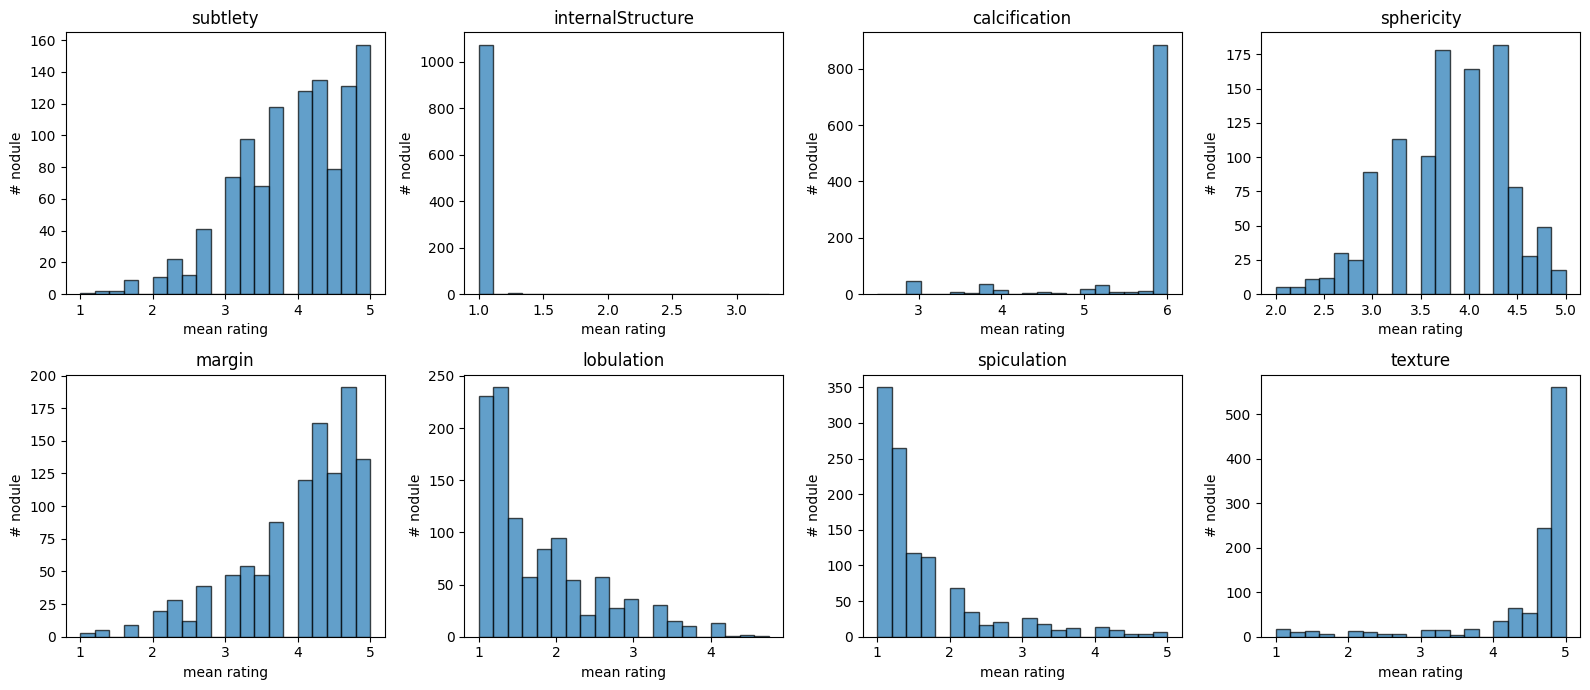

In [ ]:
# Histogramlar
valid = nodules_df.dropna(subset=CONCEPT_COLS).copy()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, col in enumerate(CONCEPT_COLS):
    ax = axes[i//4, i%4]
    ax.hist(valid[col], bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(col.replace('_mean', ''))
    ax.set_xlabel('mean rating')
    ax.set_ylabel('# nodule')
plt.tight_layout()
plt.show()

### Korelasyon — concept'ler ile malignancy_mean arasında

Klinik beklenti:
- `spiculation` ↔ malignancy: yüksek pozitif (malign nodüller iğneli)
- `margin` ↔ malignancy: negatif (malign kenarları belirsiz olabilir)
- `texture` ↔ malignancy: pozitif olabilir (solid nodüller daha sık malign)
- `calcification` ↔ malignancy: negatif (kireçlenmiş nodüller genelde benign)
- `sphericity` ↔ malignancy: negatif olabilir (malignler bozulmuş şekilli)

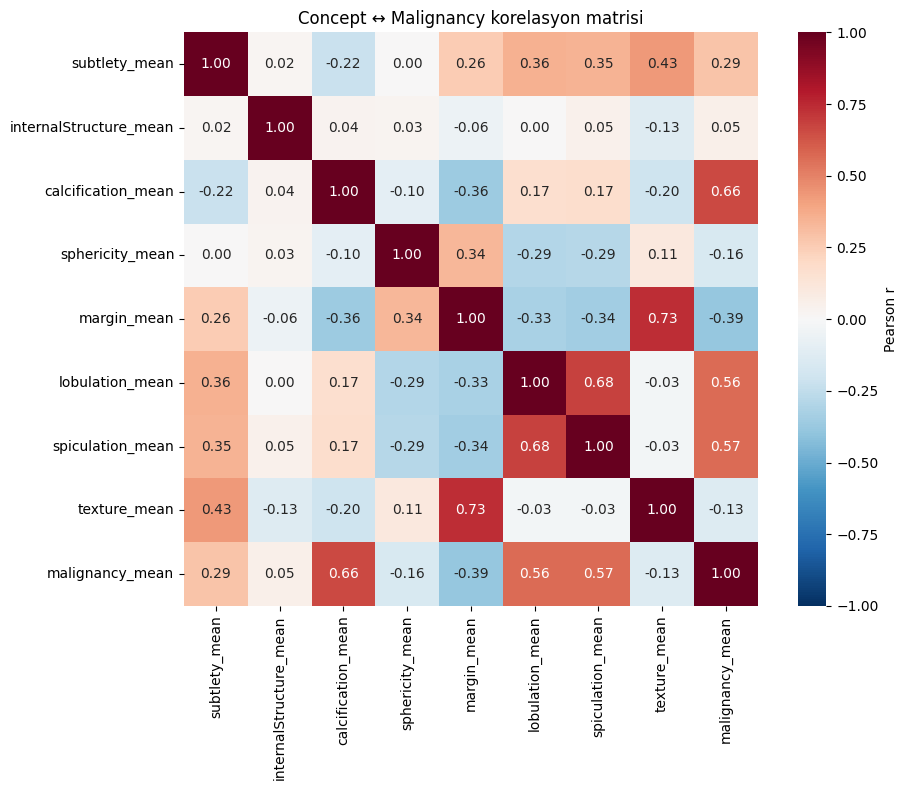


Malignancy ile en yüksek korelasyonlar:
  + calcification_mean            : r = +0.658
  + spiculation_mean              : r = +0.570
  + lobulation_mean               : r = +0.565
  - margin_mean                   : r = -0.390
  + subtlety_mean                 : r = +0.288
  - sphericity_mean               : r = -0.156
  - texture_mean                  : r = -0.135
  + internalStructure_mean        : r = +0.055


In [ ]:
# Korelasyon matrisi
corr_cols = CONCEPT_COLS + ['malignancy_mean']
corr_matrix = valid[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Concept ↔ Malignancy korelasyon matrisi')
plt.tight_layout()
plt.show()

print('\nMalignancy ile en yüksek korelasyonlar:')
mal_corr = corr_matrix['malignancy_mean'].drop('malignancy_mean').abs().sort_values(ascending=False)
for col, r in mal_corr.items():
    sign = '+' if corr_matrix.loc[col, 'malignancy_mean'] > 0 else '-'
    print(f'  {sign} {col:30s}: r = {corr_matrix.loc[col, "malignancy_mean"]:+.3f}')

## 11. H5'e yazılan concepts'i doğrula

In [ ]:
# Train H5'ten örnek bir pozitif çek ve concept'lerini göster
with h5py.File(TRAIN_H5, 'r') as h5:
    det = h5['detection'][:]
    concepts = h5['concepts'][:]

    pos_indices = np.where((det == 1) & (concepts[:, 0] > 0))[0]
    if len(pos_indices) == 0:
        print('⚠️ Pozitif + concept\'i olan örnek bulunamadı')
    else:
        idx = np.random.choice(pos_indices)
        sid = h5['seriesuids'][idx]
        if isinstance(sid, bytes): sid = sid.decode()
        coord = h5['world_coords'][idx]
        mal = h5['malignancy'][idx]

        print(f'Pozitif örnek [{idx}]:')
        print(f'  seriesuid: {sid[:35]}...')
        print(f'  world coord: ({coord[0]:.1f}, {coord[1]:.1f}, {coord[2]:.1f})')
        print(f'  malignancy: {mal} (0=benign, 1=malign)')
        print(f'\n  Concept\'ler:')
        for i, col in enumerate(CONCEPT_COLS):
            print(f'    {col:30s}: {concepts[idx][i]:.2f}')

    # İstatistikler
    pos_concepts = concepts[(det == 1) & (concepts[:, 0] > 0)]
    neg_default = (concepts[det == 0] == -1.0).all(axis=1).sum()
    print(f'\n  Toplam pozitif örnek: {(det == 1).sum()}')
    print(f'  Concept\'i olan pozitif: {len(pos_concepts)}')
    print(f'  Concept = -1 olan negatif: {neg_default}/{(det == 0).sum()} (beklenen: hepsi)')

Pozitif örnek [775]:
  seriesuid: 1.3.6.1.4.1.14519.5.2.1.6279.6001.6...
  world coord: (-60.4, -50.5, -171.1)
  malignancy: 0 (0=benign, 1=malign)

  Concept'ler:
    subtlety_mean                 : 3.50
    internalStructure_mean        : 1.00
    calcification_mean            : 6.00
    sphericity_mean               : 4.25
    margin_mean                   : 4.75
    lobulation_mean               : 1.50
    spiculation_mean              : 1.00
    texture_mean                  : 5.00

  Toplam pozitif örnek: 870
  Concept'i olan pozitif: 859
  Concept = -1 olan negatif: 5000/5000 (beklenen: hepsi)


## 12. Özet

In [ ]:
summary = f'''
============================================================
NOTEBOOK 4 — CONCEPT EXTRACTION ÖZET
============================================================

✅ {N_CONCEPTS} concept LIDC'den çıkarıldı
✅ nodules.csv güncellendi: 8 yeni kolon
✅ 3 H5 dosyasına 'concepts' dataset eklendi

📂 Eşleşme oranları:
  Train: {results["train"][0]}/{results["train"][1]} ({results["train"][0]/max(results["train"][1],1)*100:.0f}%)
  Val:   {results["val"][0]}/{results["val"][1]} ({results["val"][0]/max(results["val"][1],1)*100:.0f}%)
  Test:  {results["test"][0]}/{results["test"][1]} ({results["test"][0]/max(results["test"][1],1)*100:.0f}%)

🎯 Sıradaki: Notebook 5 — Concept Bottleneck Multi-task Model
  • Pretrained ViT-L encoder (DAPT epoch 3 ckpt)
  • Detection head (binary)
  • Segmentation head (UNETR-style decoder)
  • Concept head ({N_CONCEPTS} outputs, regresyon)
  • Malignancy head (binary, concept'lerden lineer)
'''
print(summary)


NOTEBOOK 4 — CONCEPT EXTRACTION ÖZET

✅ 8 concept LIDC'den çıkarıldı
✅ nodules.csv güncellendi: 8 yeni kolon
✅ 3 H5 dosyasına 'concepts' dataset eklendi

📂 Eşleşme oranları:
  Train: 859/870 (99%)
  Val:   100/100 (100%)
  Test:  129/130 (99%)

🎯 Sıradaki: Notebook 5 — Concept Bottleneck Multi-task Model
  • Pretrained ViT-L encoder (DAPT epoch 3 ckpt)
  • Detection head (binary)
  • Segmentation head (UNETR-style decoder)
  • Concept head (8 outputs, regresyon)
  • Malignancy head (binary, concept'lerden lineer)

